<a href="https://colab.research.google.com/github/CadeJMock/assg06_aidatasci/blob/main/Assg06_aidatasci.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Question 1

In [ ]:
# necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# lets look at just at a snippet of our dataset to get a basic understanding
customer_data = pd.read_csv('/content/Customers.csv')
print(customer_data)

     CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0             1    Male   19                  15                      39
1             2    Male   21                  15                      81
2             3  Female   20                  16                       6
3             4  Female   23                  16                      77
4             5  Female   31                  17                      40
..          ...     ...  ...                 ...                     ...
195         196  Female   35                 120                      79
196         197  Female   45                 126                      28
197         198    Male   32                 126                      74
198         199    Male   32                 137                      18
199         200    Male   30                 137                      83

[200 rows x 5 columns]


We have five columns, and only one is a categorical column. This categorical column is in a binary of Male and Female - so this is good for one hot encoding later. Also, we should take note that the "CustomerID" column is just an ID column, so we may just drop it unless it is needed in later questions.</br></br>
Lets check out some more info to double check for any missing values, information, and summary stats for our numerical features.

In [ ]:
customer_data.drop('CustomerID', axis = 1, inplace = True)
print(customer_data.head())

    Genre  Age  Annual Income (k$)  Spending Score (1-100)
0    Male   19                  15                      39
1    Male   21                  15                      81
2  Female   20                  16                       6
3  Female   23                  16                      77
4  Female   31                  17                      40


We have successfuly removed the customer ID field, now we can move on with further analysis.

In [ ]:
print("Dataset Information:")
print(customer_data.info()) # display info about the dataset
print("\nMissing values in each column:")
print(customer_data.isnull().sum) # check for missing values
print("\nSummary statistics for numerical features:")
print(customer_data.describe()) # display summary stats for numerical features

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Genre                   200 non-null    object
 1   Age                     200 non-null    int64 
 2   Annual Income (k$)      200 non-null    int64 
 3   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 6.4+ KB
None

Missing values in each column:
<bound method DataFrame.sum of      Genre    Age  Annual Income (k$)  Spending Score (1-100)
0    False  False               False                   False
1    False  False               False                   False
2    False  False               False                   False
3    False  False               False                   False
4    False  False               False                   False
..     ...    ...                 ...                     ...
195  False 

We can get a decent overview of our our dataset, most importantly we can see we have no missing values in any of our entries. There are some good infomration in the summary statistics in case we need to remove any outliers like using the 25%, 50%, and 75% portions using the IQR method.</br></br>

Lets start visualizing the distribution of each feature.

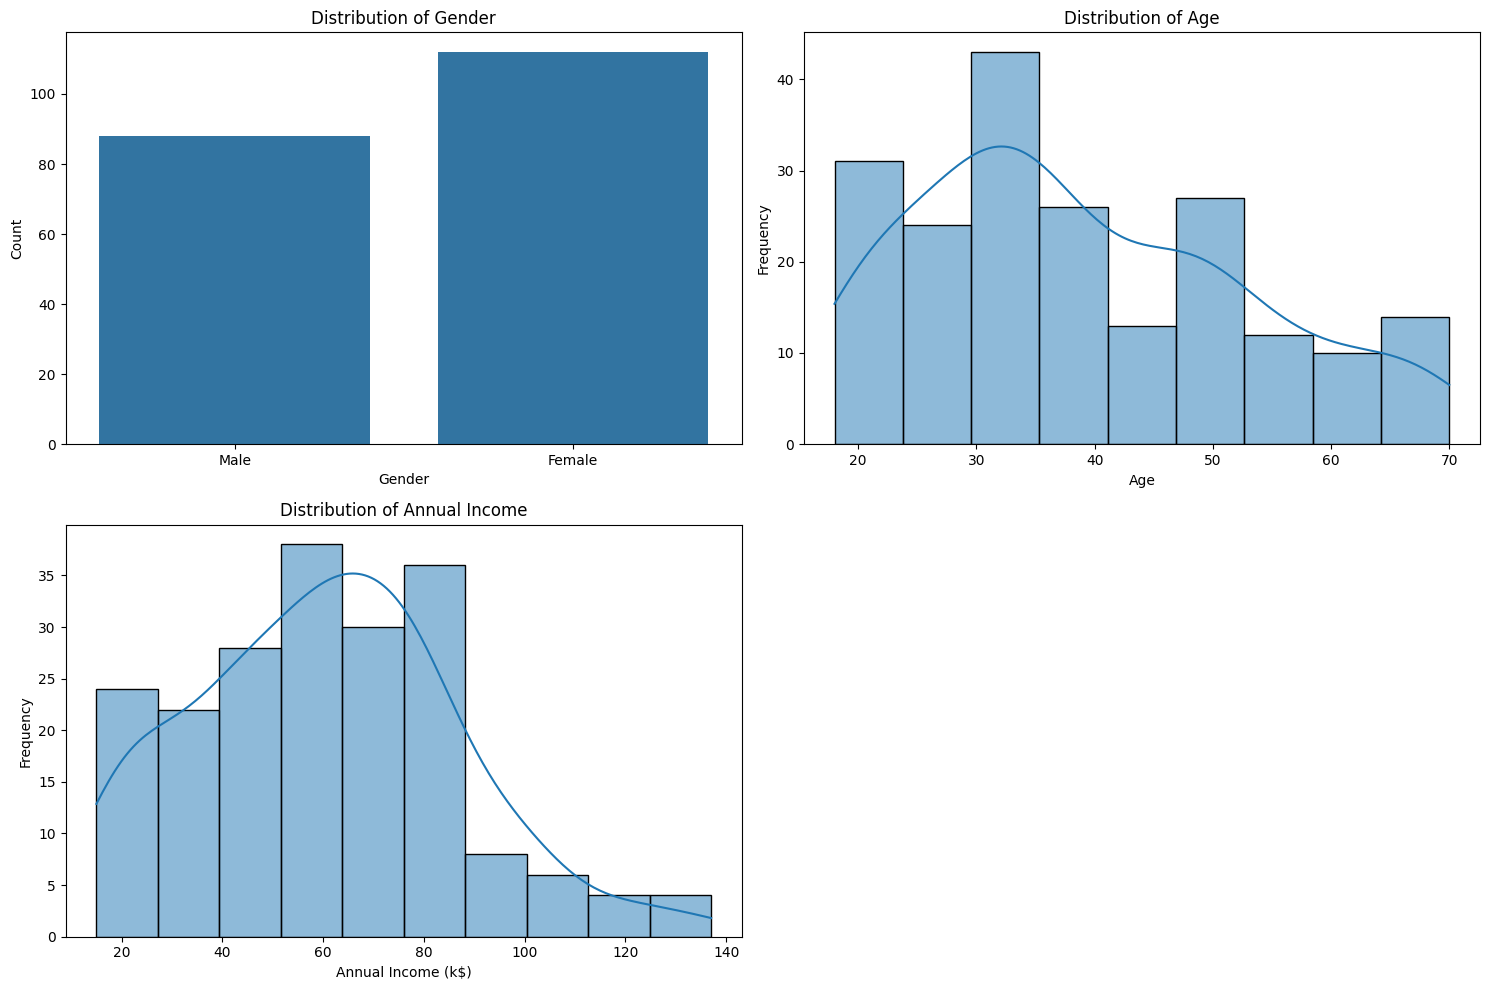

In [ ]:
# figure layout
plt.figure(figsize=(15, 10))

# categorical feature (genre, meant to be gender? probably)
plt.subplot(2, 2, 1)
sns.countplot(x='Genre', data=customer_data)
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')

# numerical features
plt.subplot(2, 2, 2)
sns.histplot(customer_data['Age'], kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.subplot(2, 2, 3)
sns.histplot(customer_data['Annual Income (k$)'], kde=True)
plt.title('Distribution of Annual Income')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Our distributions don't look super skewed, although for the income we can might be able to say intuitively that some of the higher annual incomes may be considered outliers and negatively effect our training on this data, but it also could be important.</br></br>

Now, lets do some box plots for our numerical features.

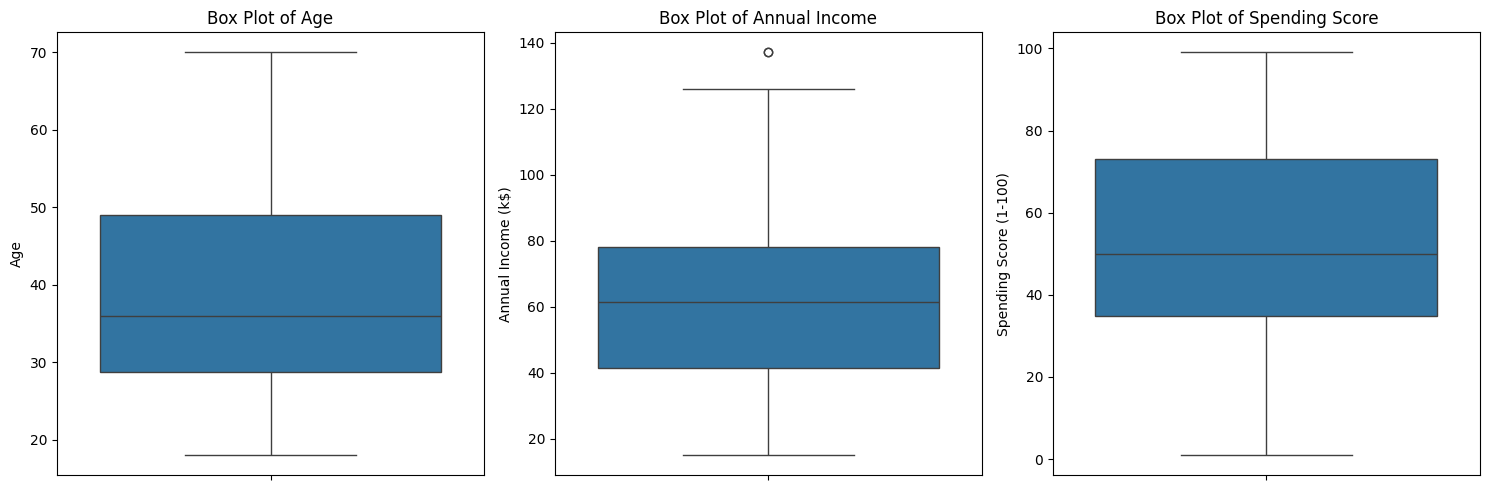

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=customer_data['Age'])
plt.title('Box Plot of Age')
plt.ylabel('Age')

plt.subplot(1, 3, 2)
sns.boxplot(y=customer_data['Annual Income (k$)'])
plt.title('Box Plot of Annual Income')
plt.ylabel('Annual Income (k$)')

plt.subplot(1, 3, 3)
sns.boxplot(y=customer_data['Spending Score (1-100)'])
plt.title('Box Plot of Spending Score')
plt.ylabel('Spending Score (1-100)')

plt.tight_layout()
plt.show()

We don't seem to really have any outliers besides one annual income entry, I don't think its very important to remove it for now.</br></br>

Now, since this is distributed between two genders, lets make some plots to view the different distributions between the two genders.

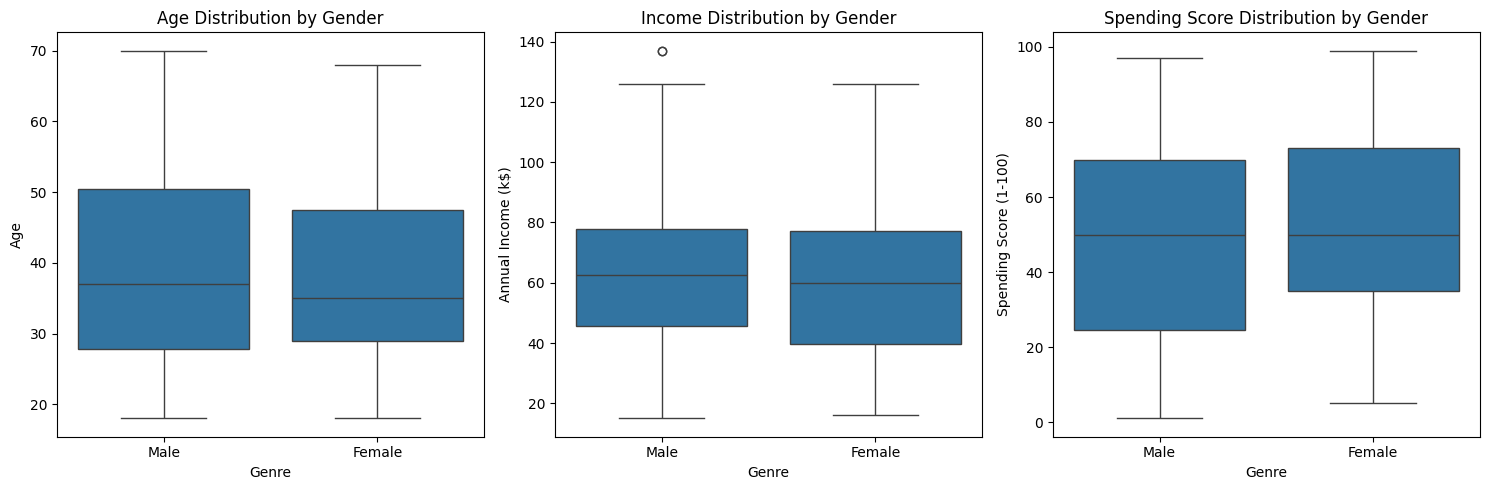

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(x='Genre', y='Age', data=customer_data)
plt.title('Age Distribution by Gender')

plt.subplot(1, 3, 2)
sns.boxplot(x='Genre', y='Annual Income (k$)', data=customer_data)
plt.title('Income Distribution by Gender')

plt.subplot(1, 3, 3)
sns.boxplot(x='Genre', y='Spending Score (1-100)', data=customer_data)
plt.title('Spending Score Distribution by Gender')

plt.tight_layout()
plt.show()

From our data, we can see that we have a slightly older male demographic, more females earn less than some men, and females have a higher spending score than males.</br></br>

 Before we move on, lets one hot encode our gender to binary so we can view its effect on the correlation heatmap.

In [ ]:
# https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html
# https://www.reddit.com/r/learnpython/comments/e0yqim/what_is_get_dummies_in_pandas/
customer_data['Genre'] = customer_data['Genre'].map({'Male': 1, 'Female': 0})
print(customer_data)

     Genre  Age  Annual Income (k$)  Spending Score (1-100)
0        1   19                  15                      39
1        1   21                  15                      81
2        0   20                  16                       6
3        0   23                  16                      77
4        0   31                  17                      40
..     ...  ...                 ...                     ...
195      0   35                 120                      79
196      0   45                 126                      28
197      1   32                 126                      74
198      1   32                 137                      18
199      1   30                 137                      83

[200 rows x 4 columns]


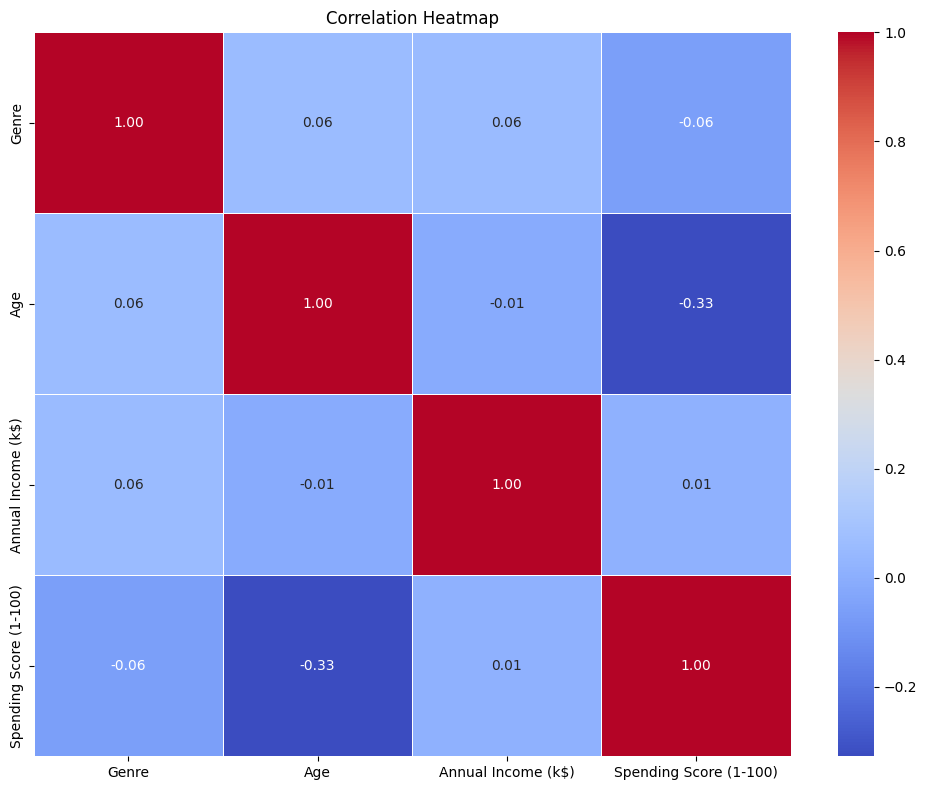

In [ ]:
# lets select only numerical columns for the heatmap
numerical_data = customer_data.select_dtypes(include=[np.number])

# calculate the correlation matrix
correlation_matrix = numerical_data.corr()

# create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

There doesn't seem to really be any correlation available for us to see. The only thing we can note is the negative relationship of -0.33 between Age and Spending Score, showing that younger people tend to have slightly lower spending score.</br></br>

Now, lets use some pair plots for visualizaing relationships between the features.

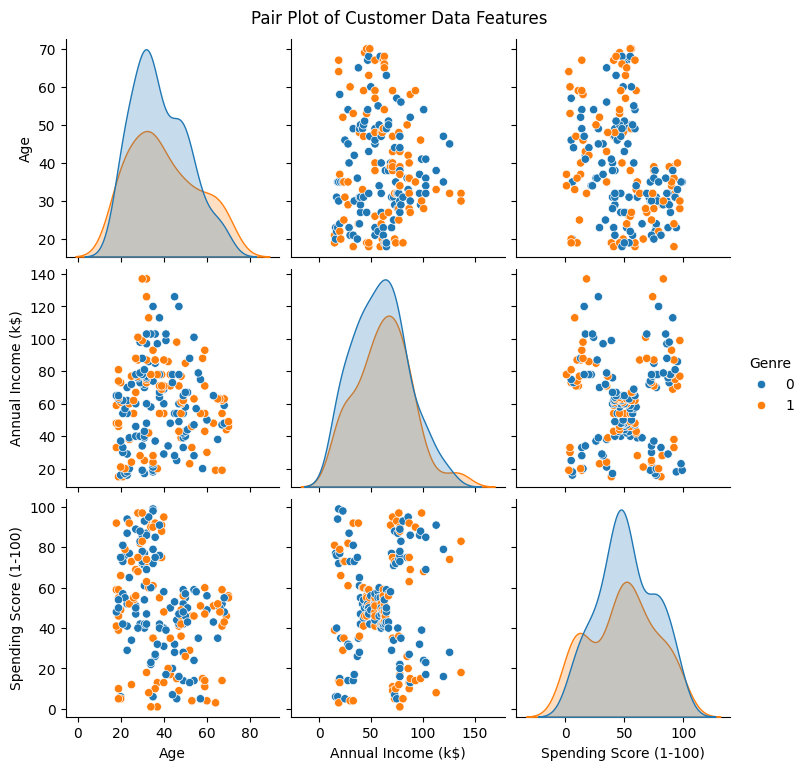

In [ ]:
# https://seaborn.pydata.org/generated/seaborn.pairplot.html
# https://stackoverflow.com/questions/56188305/matplotlib-to-plot-a-pairplot

sns.pairplot(customer_data, hue='Genre')
plt.suptitle('Pair Plot of Customer Data Features', y=1.02)
plt.show()

# Question 2

In [ ]:
# lets start by selecting the required features for clustering
X = customer_data[['Annual Income (k$)', 'Spending Score (1-100)']]

# display the first few rows of the selected features
print("Selected features for clustering:")
print(X.head())

# display basic statistics of the selected features
print("\nStatistics of selected features:")
print(X.describe())

Selected features for clustering:
   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40

Statistics of selected features:
       Annual Income (k$)  Spending Score (1-100)
count          200.000000              200.000000
mean            60.560000               50.200000
std             26.264721               25.823522
min             15.000000                1.000000
25%             41.500000               34.750000
50%             61.500000               50.000000
75%             78.000000               73.000000
max            137.000000               99.000000


Now lets visualizae the selected features to explore their location and distribution for clustering. I wanted to experiment with a 3D plot, and some other things, so I followed a lot of tutorials and guides from resources online to get some better visuals on our features. I will paste the resources in the Python code.

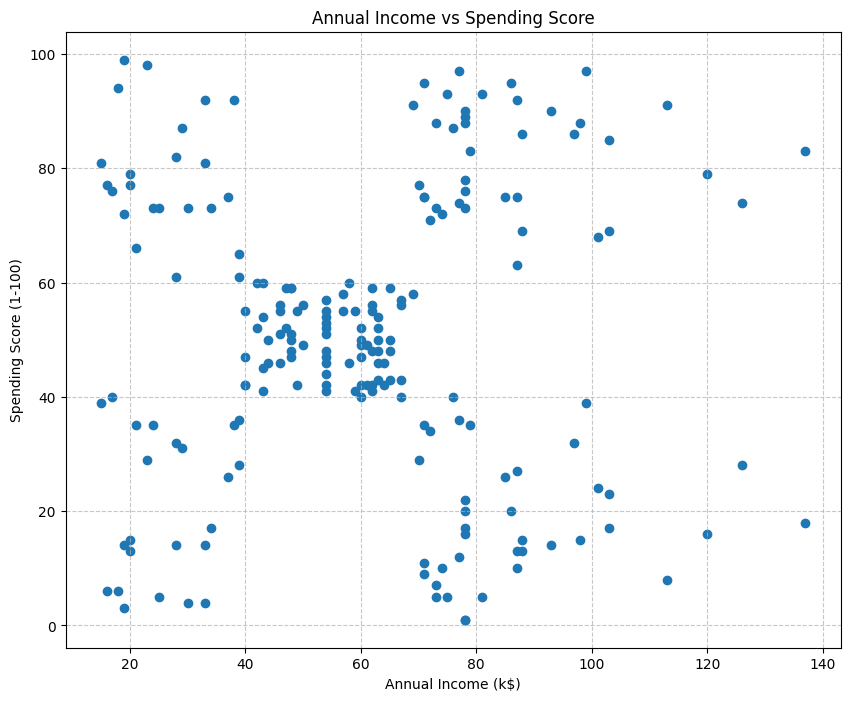

<Figure size 1000x800 with 0 Axes>

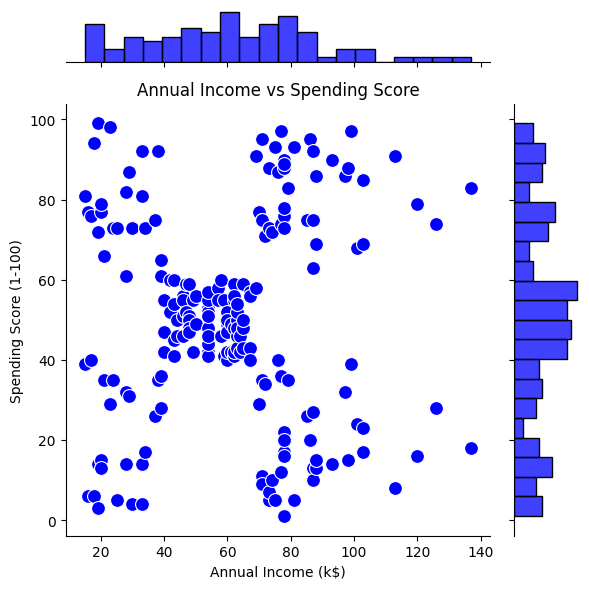

<Figure size 1000x800 with 0 Axes>

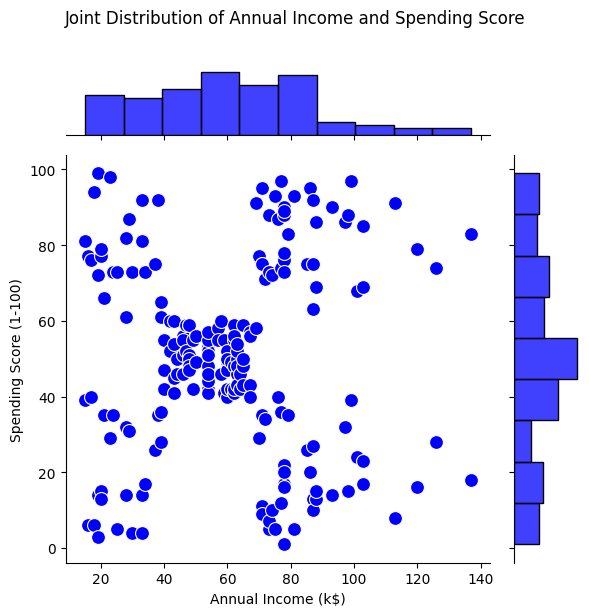

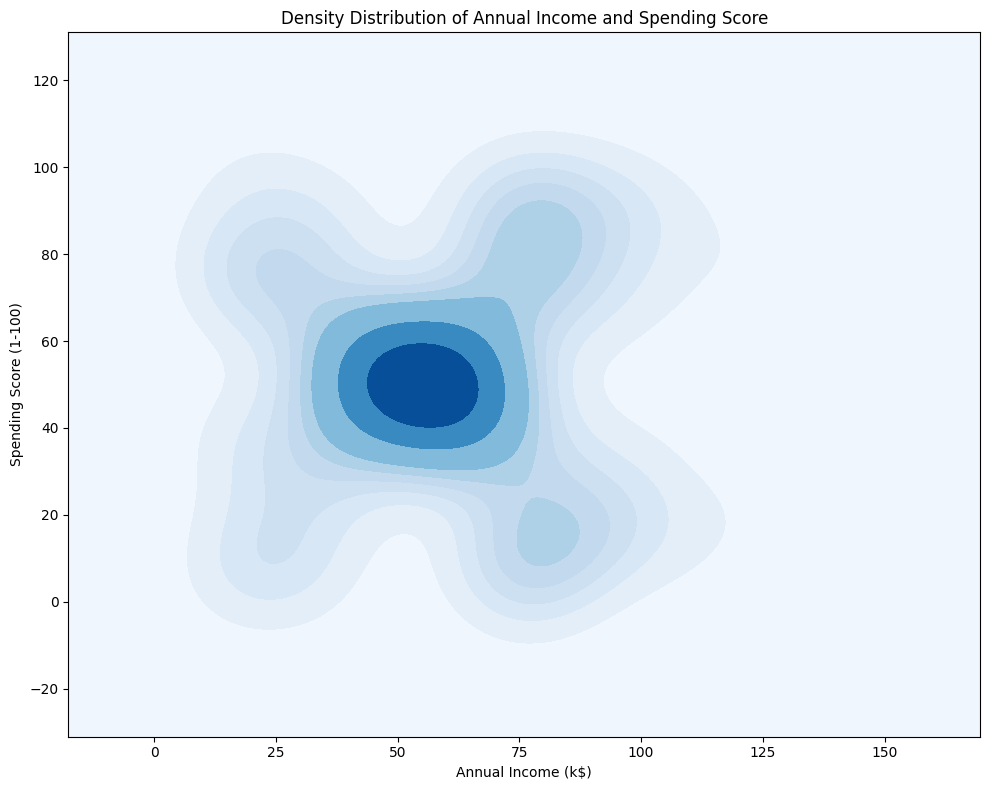

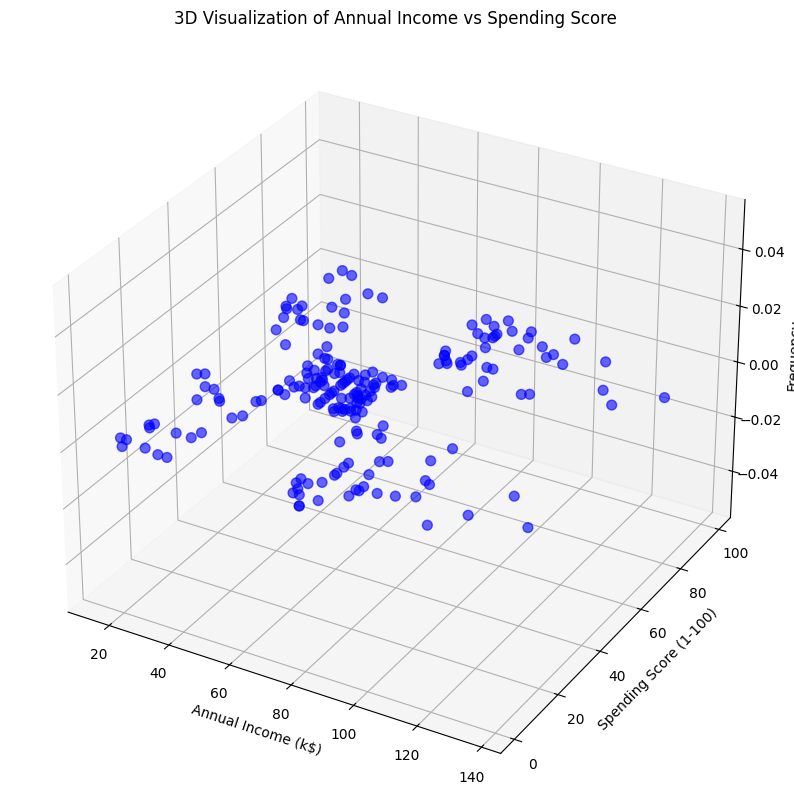

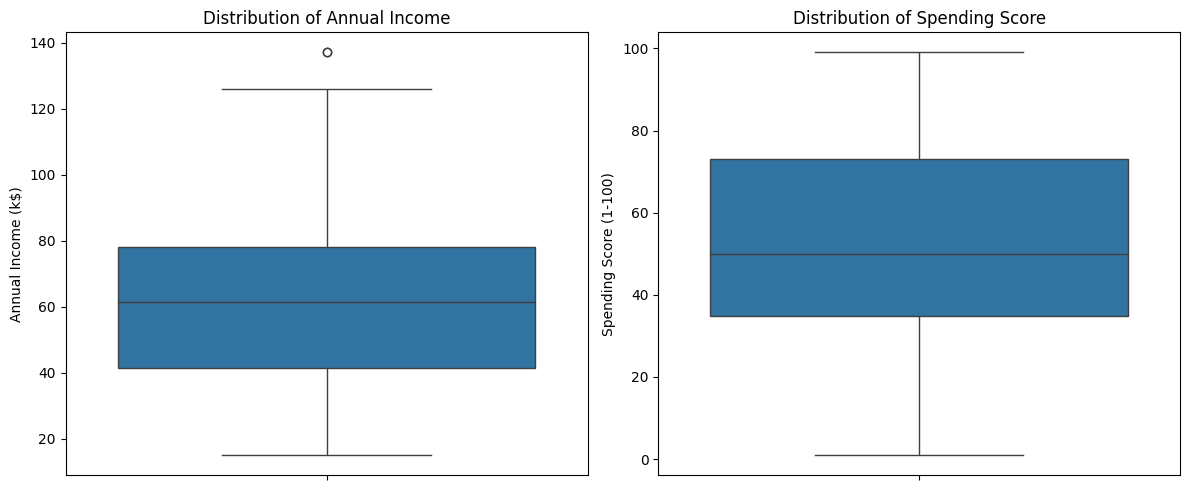

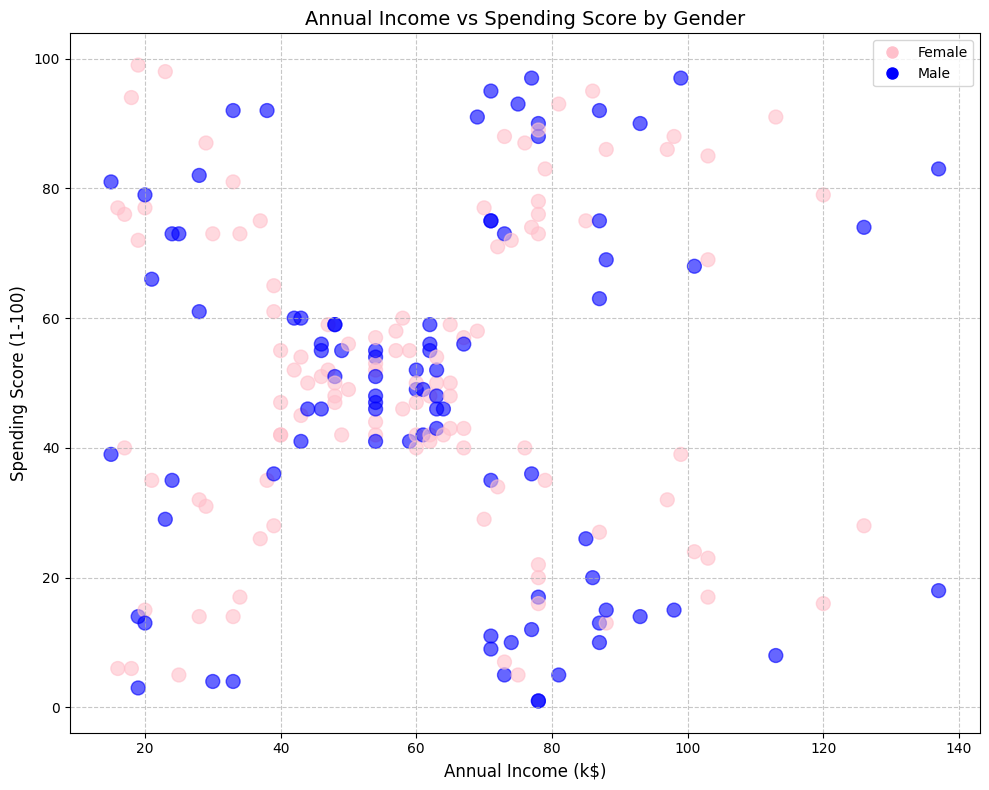

In [ ]:
# Now lets visualize the selected features.
# References:
# https://docs.kanaries.net/articles/clustering-visualization
# https://medium.com/@jwbtmf/visualizing-data-using-k-means-clustering-unsupervised-machine-learning-8b59eabfcd3d
# https://help.relativity.com/RelativityOne/Content/Relativity/Analytics/Cluster_visualization.htm
# https://www.kaggle.com/code/naren3256/kmeans-clustering-and-cluster-visualization-in-3d
# https://medium.com/data-science/visualizing-clusters-with-pythons-matplolib-35ae03d87489
# https://seaborn.pydata.org/generated/seaborn.jointplot.html
# https://seaborn.pydata.org/archive/0.11/generated/seaborn.jointplot.html
# https://matplotlib.org/stable/users/explain/toolkits/mplot3d.html
# https://matplotlib.org/stable/api/toolkits/mplot3d.html
# https://seaborn.pydata.org/generated/seaborn.jointplot.html
# https://seaborn.pydata.org/generated/seaborn.jointplot.html
# https://seaborn.pydata.org/archive/0.11/generated/seaborn.jointplot.html
# https://www.analyticsvidhya.com/blog/2024/02/a-comprehensive-guide-to-seaborn-jointplots/

# scatter plot of Annual Income vs Spending Score
plt.figure(figsize=(10, 8))
plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'])
plt.title('Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


# create a jointplot to see distributions along with scatter plot
plt.figure(figsize=(10, 8))
sns.jointplot(x='Annual Income (k$)', y='Spending Score (1-100)', data=X, kind='scatter', s=100, color='blue', marginal_kws=dict(bins=20, fill=True))
plt.title('Annual Income vs Spending Score')
plt.tight_layout()
plt.show()

# lets create a jointplot to see distributions along with scatter plot
plt.figure(figsize=(10, 8))
sns.jointplot(x='Annual Income (k$)', y='Spending Score (1-100)',
             data=X, kind='scatter', s=100, color='blue')
plt.suptitle('Joint Distribution of Annual Income and Spending Score', y=1.02)
plt.tight_layout()
plt.show()

# create a 2D KDE plot to visualize the density distribution
plt.figure(figsize=(10, 8))
sns.kdeplot(data=X, x='Annual Income (k$)', y='Spending Score (1-100)', cmap='Blues', fill=True, thresh=0)
plt.title("Density Distribution of Annual Income and Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.tight_layout()
plt.show()

# 3D visualization for better understanding of the distribution
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 10))
ax  = fig.add_subplot(111, projection='3d')

# scatter plot of Annual Income vs Spending Score
ax.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'],
           np.zeros_like(X['Annual Income (k$)']),
           c='blue', s=50, alpha=0.6)

ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Spending Score (1-100)')
ax.set_zlabel('Frequency')
ax.set_title('3D Visualization of Annual Income vs Spending Score')
plt.show()


# Box plots to show distributions of each feature individually
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=X['Annual Income (k$)'])
plt.title('Distribution of Annual Income', fontsize=12)

plt.subplot(1, 2, 2)
sns.boxplot(y=X['Spending Score (1-100)'])
plt.title('Distribution of Spending Score', fontsize=12)

plt.tight_layout()
plt.show()



# Visualize with color-coded gender
plt.figure(figsize=(10, 8))
gender_colors = {0: 'pink', 1: 'blue'}  # 0=Female, 1=Male
plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'],
            c=customer_data['Genre'].map(gender_colors), s=100, alpha=0.6)
plt.title('Annual Income vs Spending Score by Gender', fontsize=14)
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)


# Add a legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w',
                          markerfacecolor='pink', markersize=10, label='Female'),
                   Line2D([0], [0], marker='o', color='w',
                          markerfacecolor='blue', markersize=10, label='Male')]
plt.legend(handles=legend_elements)

plt.tight_layout()
plt.show()


To recap, my code created multiple visualizations to explore both the distribution and relationships between Annual Income and Spending Score for clustering. Here are some of the visualizations I made using resources online related to this:</br>
1. A basic scatter plot showing the distribution of points in the 2D space.
2. A joint plot that combines the scatter plot with histograms on each axis.
3. A 2D KDE (Kernel Density Estimation) plot showing desntiy contours.
4. A 3D visualization for another perspective on the distribution.
5. Box plots to show the distribution of each feature individually.
6. A scatter plot colored by gender to see if there are any gender-based patterns.

For the first visualization - the basic scatter plot seems to show the relationship between annual income and spending score. It reveals some patterns we can note. First of all, there appears to be natural clusters in the data - middle, high, and low spenders. These types of clusters suggest that K-means clustering may work well on this dataset.

For the second visualization - histograms show that annual income has a distribution skewed slightly to the right. Also, spending scores appear to have a multimodal distribution with peaks around 40-50, 70-80, and around 10-20. The peaks in spending score supports the presence of distinct customer segments, meaning clusterin may work well on the dataset.

For the third visualization - the plot uses color intensity to show where data points are most concentrated. The darkest blue area has the highest density and is in the middle cluster. There are other high-density regions in the upper left, upper middle-right, and lower reions. This helps confirm the cluster patterns and shows approximately 5 regions of concentration.

The fourth part involves a 3D visualization - this confirms some patterns we see in the 2D plots. The introduction of the z-axis helps visualize the densities in a way where the clustering pattern is clearly visual intuitively to us.

The fith visualization includes boxplots of individual features - these plots show the distribution of each feature separately:
- Annual income: median around 60k, IQR from about 40k to 80k
- Spending score: median around 50, IQR around 35-37 (which is a more even distribution)

Both distributions appear pretty symmetric, with only one outlier in annual income.

The last visualization adds some information by comparing the genders. The distribution of males and females appear prety similar across the clusters, and we can note that gender does not seem to be a strong determinant of our clustering pattern. Both genders appear to be represented across all potential clusters.

</br></br>**OVERALL**</br>
From all of these visualizations, we can take away that there are approximately 5 clear clusters we can see in the data:
1. Middle income, middle spenders (the largest cluster)
2. Low income, high spenders
3. High income, high spenders
4. Low income, low spenders
5. High income, low spenders

This suggests that when we move onto the other questions in this assignment, when we start using things like the elbow method to determine the optimal number of clusters, we should be expecting to find an optimal K value of around 5. Otherwise, our analysis and visualizations indicate that K-means clustering will be effective for this dataset.

# Question 3

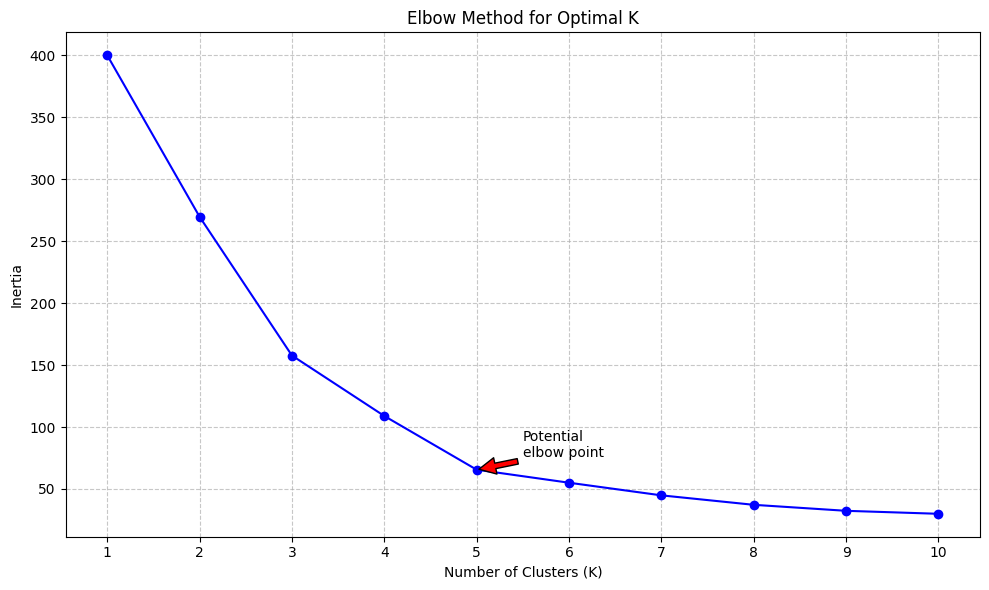

Intertia values for each K:
K=1: 400.00
K=2: 269.69
K=3: 157.70
K=4: 108.92
K=5: 65.57
K=6: 55.06
K=7: 44.86
K=8: 37.23
K=9: 32.39
K=10: 29.98

Percentage decrease in inertia:
From K=1 to K=2: 32.58%
From K=2 to K=3: 41.52%
From K=3 to K=4: 30.93%
From K=4 to K=5: 39.80%
From K=5 to K=6: 16.03%
From K=6 to K=7: 18.51%
From K=7 to K=8: 17.02%
From K=8 to K=9: 12.99%
From K=9 to K=10: 7.44%


In [ ]:
# lets reimport all our libraries
# + the new ones, that we will need for question 3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# lets regrab the dataset and features
# just so we have the variables back in mind
customer_data = pd.read_csv('/content/Customers.csv')
X = customer_data[['Annual Income (k$)', 'Spending Score (1-100)']]

# standardize our data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# calculate inertia for different values of K
inertia = []
K_range = range(1, 11) # just try K values from 1 to 10

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)


# now, we can plot the elbow graph
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, 'bo-')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.grid(True, linestyle='--', alpha=0.7)

# tip found from resources is to add annotations to highlight the potential elbow point using the following:
# note: we put it at K=5 because of our previous visual analysis
plt.annotate('Potential\nelbow point', xy=(5, inertia[4]),
             xytext=(5.5, inertia[4]+10),
             arrowprops=dict(facecolor='red', shrink=0.05))

plt.tight_layout()
plt.show()


# now lets print the inertia values for eah K
print("Intertia values for each K:")
for k, i in zip(K_range, inertia):
    print(f"K={k}: {i:.2f}")

# calculate the percetnage decrease in inertia
print("\nPercentage decrease in inertia:")
for i in range(1, len(inertia)):
    decrease = ((inertia[i-1] - inertia[i]) / inertia[i-1]) * 100
    print(f"From K={i} to K={i+1}: {decrease:.2f}%")


# references:
# https://stanford.edu/~cpiech/cs221/handouts/kmeans.html
# https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
# https://www.analyticsvidhya.com/blog/2019/08/comprehensive-guide-k-means-clustering/
# https://builtin.com/data-science/elbow-method#:~:text=The%20elbow%20method%20is%20a%20graphical%20method%20for%20finding%20the,on%20the%20x%2Daxis).
# https://www.analyticsvidhya.com/blog/2021/01/in-depth-intuition-of-k-means-clustering-algorithm-in-machine-learning/
# https://medium.com/@zalarushirajsinh07/the-elbow-method-finding-the-optimal-number-of-clusters-d297f5aeb189
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.annotate.html

After looking at the graph, and the printed observations. We can see that the intertia drops dramatically from K=1 to K=5, an overall decrease of about 84%. After K=5, the decrease becomes much smaller, providing evidence for K=5 to be the elbow point.  

The most notable drop in improvement is between K=4->5 (39.80%) and K=5->6 (16.03%), which is more than a 50% reduction in the improvement.

My prediction and annotation of the "potential elbow point" ended up correctly identifying it, and now marks where the curve visibly starts bending and flattening out. This means that adding a 6th cluster provides much less benefit than adding the 5th cluster did.

While moving onto Question 4, we should use the optimal K value of 5.

# Question 4

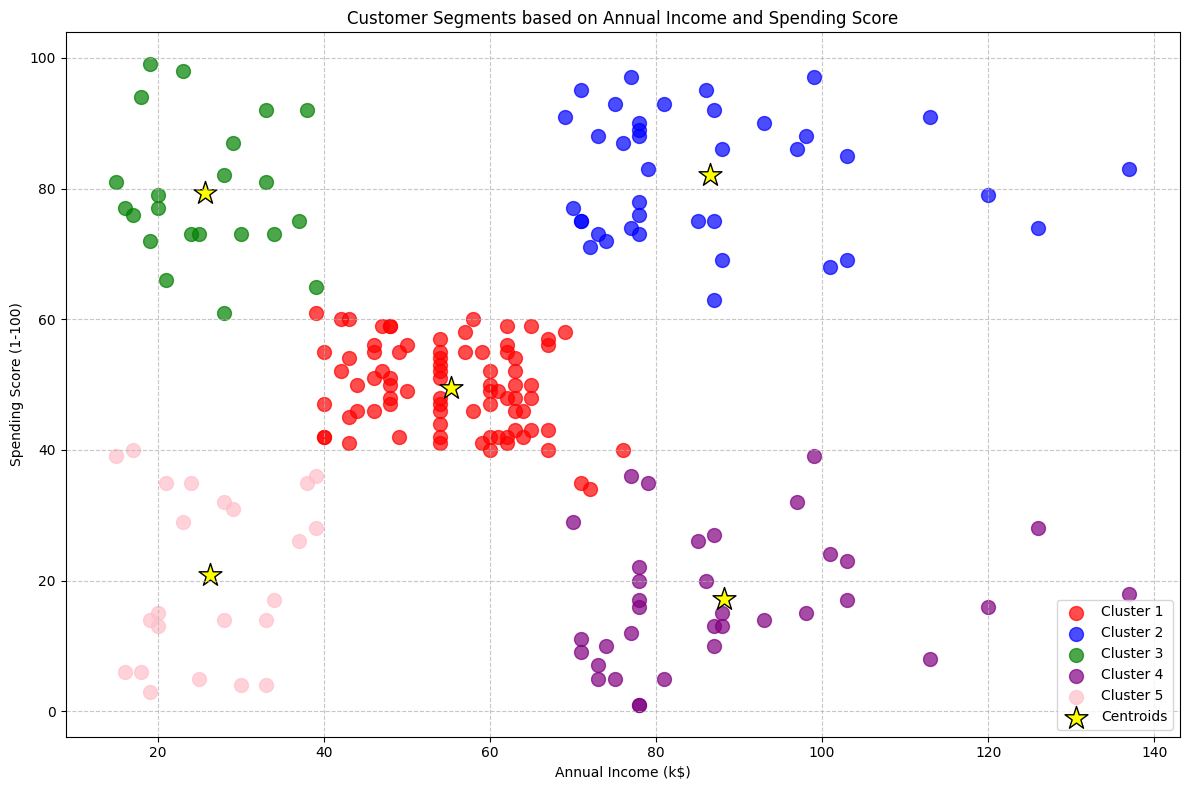

Number of customers in each cluster:
Cluster 1: 81 customers
Cluster 2: 39 customers
Cluster 3: 22 customers
Cluster 4: 35 customers
Cluster 5: 23 customers

Cluster centroids (original scale):
Cluster	Annual Income	Spending Sore (1-100)
Cluster 1	55.30		49.52
Cluster 2	86.54		82.13
Cluster 3	25.73		79.36
Cluster 4	88.20		17.11
Cluster 5	26.30		20.91

Cluster statistics:

Cluster 1:
       Annual Income (k$)  Spending Score (1-100)
count               81.00                   81.00
mean                55.30                   49.52
std                  8.99                    6.53
min                 39.00                   34.00
25%                 48.00                   44.00
50%                 54.00                   50.00
75%                 62.00                   55.00
max                 76.00                   61.00

Cluster 2:
       Annual Income (k$)  Spending Score (1-100)
count               39.00                   39.00
mean                86.54                   82.13
st

In [ ]:
# apply K-means clustering with K=5
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# get cluster labels and centroids
labels = kmeans.labels_
centroids_scaled = kmeans.cluster_centers_

# transform the centroids back to original scale
centroids = scaler.inverse_transform(centroids_scaled)

# add cluster labels to the original data
customer_data['Cluster'] = labels

# color map for the clusters
colors = ['red', 'blue', 'green', 'purple', 'pink']

# plot for visualizing the clusters and centroids
plt.figure(figsize=(12, 8))

# plot each cluster with a different color (colors[])
for i in range(k):
  # filter points in cluster i
  cluster_points = customer_data[customer_data['Cluster'] == i]

  # plot the points
  plt.scatter(
      cluster_points['Annual Income (k$)'],
      cluster_points['Spending Score (1-100)'],
      s=100,
      c=colors[i],
      label=f'Cluster {i+1}',
      alpha=0.7
  )

# now, plot the centroids
plt.scatter(
    centroids[:, 0], centroids[:, 1],
    s=300, c='yellow', marker='*', edgecolor='black',
    label='Centroids', alpha=1
)

# add the labels/title/legend
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments based on Annual Income and Spending Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# calculate the size of each cluster
cluster_sizes = customer_data['Cluster'].value_counts().sort_index()
print("Number of customers in each cluster:")
for i, size in enumerate(cluster_sizes):
  print(f"Cluster {i+1}: {size} customers")

# show the cluster centroids
print("\nCluster centroids (original scale):")
print("Cluster\tAnnual Income\tSpending Sore (1-100)")
for i, centroid in enumerate(centroids):
  print(f"Cluster {i+1}\t{centroid[0]:.2f}\t\t{centroid[1]:.2f}")

# calculate basic statistics for each cluster
print("\nCluster statistics:")
for i in range(k):
  cluster_data = customer_data[customer_data['Cluster'] == i]
  print(f"\nCluster {i+1}:")
  print(cluster_data[['Annual Income (k$)', 'Spending Score (1-100)']].describe().round(2))


# references:
# https://www.naftaliharris.com/blog/visualizing-k-means-clustering/
# https://medium.com/@jwbtmf/visualizing-data-using-k-means-clustering-unsupervised-machine-learning-8b59eabfcd3d
# https://www.reddit.com/r/Python/comments/swrcv8/visualizing_the_kmeans_clustering_algorithm/
# https://bits.csb.pitt.edu/kmeans/
# https://medium.com/@sachinsoni600517/the-art-and-science-of-k-means-clustering-a-practical-guide-e71b11638867#:~:text=Visualizing%20the%20Clusters%3A,the%20centroids%20of%20other%20clusters.
# https://www.datacamp.com/datalab/templates/recipe-python-k-means
# https://stackoverflow.com/questions/61181342/how-to-graph-centroids-with-kmeans
# https://stackoverflow.com/questions/27060527/how-to-visualize-k-means-centroids-for-each-iteration/27062052

Our clustering algorithm successfully segments the customers into 5 distinct groups based on their annual income and spending score. By using the elbow method, we confirmed that 5 is the optimal number of clusters, which has become visually evident by the clear groups shown in the scatter plot.

We can use this plot, as well as the data of the clusters such as the mean annual income and spending scores to target different groups differently. We can name these clusters, for example cluster 1 has a mean annual income of $55.30k and a spending score of 49.52, which means we can label these (compared to the other clusters) a sort of middle-income or average spenders group. If this was a real life example, management and marketing at a company could use these clustering to generate effective market strategies.

**Name:** Cade Mock</br>
**CWID:** 50350556</br>
**CLASS:** CSCI-497-02B</br>
**ASSIGNMENT:** Assignment 06 Unsupervised ML-Kmeans</br>